In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

0. energy distribution of neutrino from muon decay (muon rest frame)

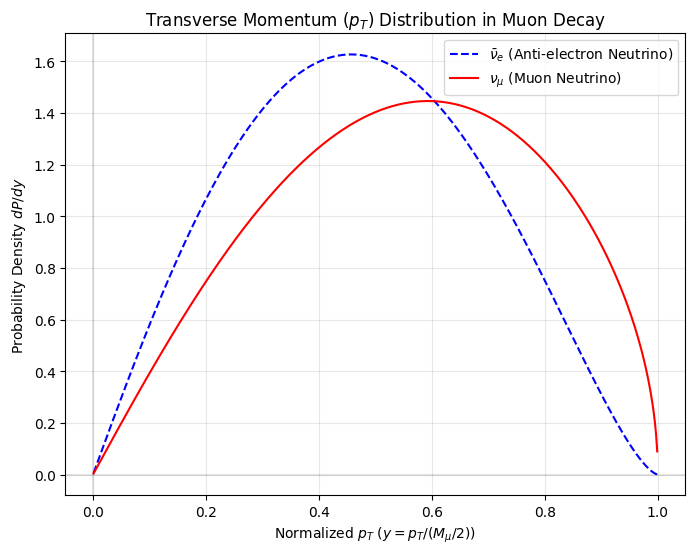

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pt_distribution():
    # y is pT / E_max, range (0, 1)
    y = np.linspace(0.001, 0.999, 500)
    
    # Common terms
    sqrt_term = np.sqrt(1 - y**2)
    log_term = np.log((1 + sqrt_term) / y) # This is arccosh(1/y)
    
    # 1. Anti-electron neutrino (should be softer)
    # Formula: 6y*sqrt - 6y^3*log
    f_nue_bar = 6 * y * sqrt_term - 6 * y**3 * log_term
    
    # 2. Muon neutrino (should be harder)
    # Formula: 4y*sqrt - 2y^3*log
    f_numu = 4 * y * sqrt_term - 2 * y**3 * log_term
    
    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(y, f_nue_bar, label=r'$\bar{\nu}_e$ (Anti-electron Neutrino)', color='blue', linestyle='--')
    plt.plot(y, f_numu, label=r'$\nu_\mu$ (Muon Neutrino)', color='red')
    
    plt.title(r'Transverse Momentum ($p_T$) Distribution in Muon Decay')
    plt.xlabel(r'Normalized $p_T$ ($y = p_T / (M_\mu/2)$)')
    plt.ylabel(r'Probability Density $dP/dy$')
    plt.axvline(x=0, color='k', alpha=0.1)
    plt.axhline(y=0, color='k', alpha=0.1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_pt_distribution()

0.1 pT distribution of neutrino from muon decay (muon has 5 TeV)

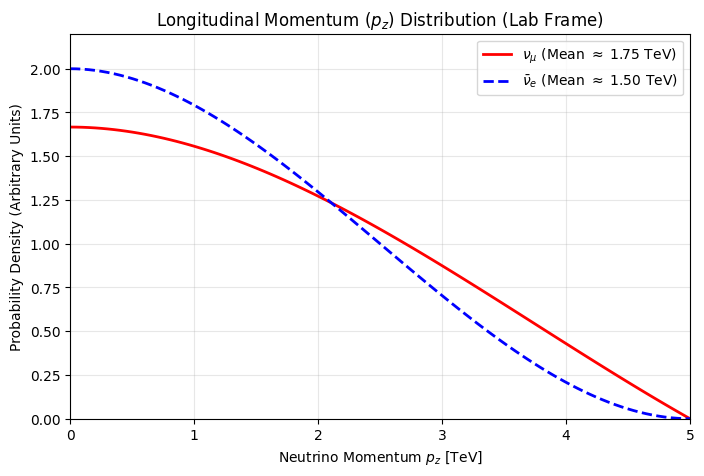

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lab_momentum():
    z = np.linspace(0, 1, 100) # fraction of muon energy
    E_mu = 5.0 # TeV
    p_z = z * E_mu
    
    # Flux formulas derived from boosting the rest frame spectrum
    # These represent dN/dz
    flux_numu = 5.0/3.0 - 3*z**2 + (4.0/3.0)*z**3
    flux_nue_bar = 2.0 - 6*z**2 + 4*z**3
    
    plt.figure(figsize=(8, 5))
    plt.plot(p_z, flux_numu, label=r'$\nu_\mu$ (Mean $\approx$ 1.75 TeV)', color='red', linewidth=2)
    plt.plot(p_z, flux_nue_bar, label=r'$\bar{\nu}_e$ (Mean $\approx$ 1.50 TeV)', color='blue', linestyle='--', linewidth=2)
    
    plt.title(r'Longitudinal Momentum ($p_z$) Distribution (Lab Frame)')
    plt.xlabel('Neutrino Momentum $p_z$ [TeV]')
    plt.ylabel('Probability Density (Arbitrary Units)')
    plt.xlim(0, 5)
    plt.ylim(0, 2.2)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_lab_momentum()

1. Numerical simulation of neutrino flux from muon decay within the main straight line

In [12]:
import pandas as pd
import numpy as np
# 你的文件路径
target_file = "E:\\李沛然\\课程\\物理\\Particle research\\neutrino_muc\\sample_boost\\boostvm.csv"

# 读取文件
# header=None 是关键：因为你刚才写入时似乎没有写表头(Column names)
# 如果不加这个，第一行数据会被误认为是列名
df = pd.read_csv(target_file, header=None)


# 如果你想把数据转回成 list of lists (像你写入时的 data_output[j] 那样)
vm_list = df.values.tolist()
print(vm_list[1][0])  # [PID, E, px, py, pz]

14.0


In [14]:
z = [float(x) for x in range(-150, 151, 2)]
d = [0.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]
vm_arr = np.array(vm_list) 
z_arr = np.array(z) # 确保 z 也是 array

# =================================================================
# 必须定义这个“任务包”，否则 Python 无法把代码发给别的核
# 我直接把你的内层循环逻辑复制进去了
# =================================================================
def run_logic_for_chunk(vm_chunk, d_val, z_all):
    result_chunk = []
    # 这里的 vm_chunk 是一小部分 vm_list
    for i in range(len(vm_chunk)):
        # 1. 提取粒子参数
        px_vm = vm_chunk[i][2]
        py_vm = vm_chunk[i][3]
        pz_vm = vm_chunk[i][4]
        pt = np.sqrt(px_vm**2 + py_vm**2)
        tan_theta = pt / pz_vm
        
        # 2. 对 Z 进行循环 (你的原始逻辑)
        # 稍微优化：利用 numpy 的布尔索引代替 if continue，速度快 10 倍
        # 筛选出满足 z < d 的部分
        valid_z = z_all[z_all < d_val]
        
        # 计算结果并加入列表
        # (d - z) * tan_theta
        vals = (d_val - valid_z) * tan_theta
        result_chunk.extend(vals)
        
    return result_chunk

# =================================================================
# 主循环 (这里启用多核)
# =================================================================
rho = []

# 将 vm_arr 切分成多个小块，分给不同的 CPU 核去算
# n_jobs=-1 表示用满所有 CPU 核心
n_cores = -1 
# 将数据切分成比如 32 份 (或者根据你的核数调整)
vm_chunks = np.array_split(vm_arr, 32) 

print("Start Parallel Calculation...")

for k in range(len(d)):
    # 这里并没有改动你的外层逻辑，只是把内层交给了 Parallel
    # Parallel 会同时处理多个 vm_chunks
    results = Parallel(n_jobs=n_cores)(
        delayed(run_logic_for_chunk)(chunk, d[k], z_arr) for chunk in vm_chunks
    )
    
    # results 是一个列表的列表，我们需要把它展平放进 rho[k]
    # 相当于原来的 rho[k].append(...)
    flat_results = [item for sublist in results for item in sublist]
    rho.append(flat_results)
    
    print(f"Finished d = {d[k]}")

print("All finish")

Start Parallel Calculation...
Finished d = 0.0
Finished d = 50.0
Finished d = 100.0
Finished d = 500.0
Finished d = 1000.0
Finished d = 5000.0
All finish


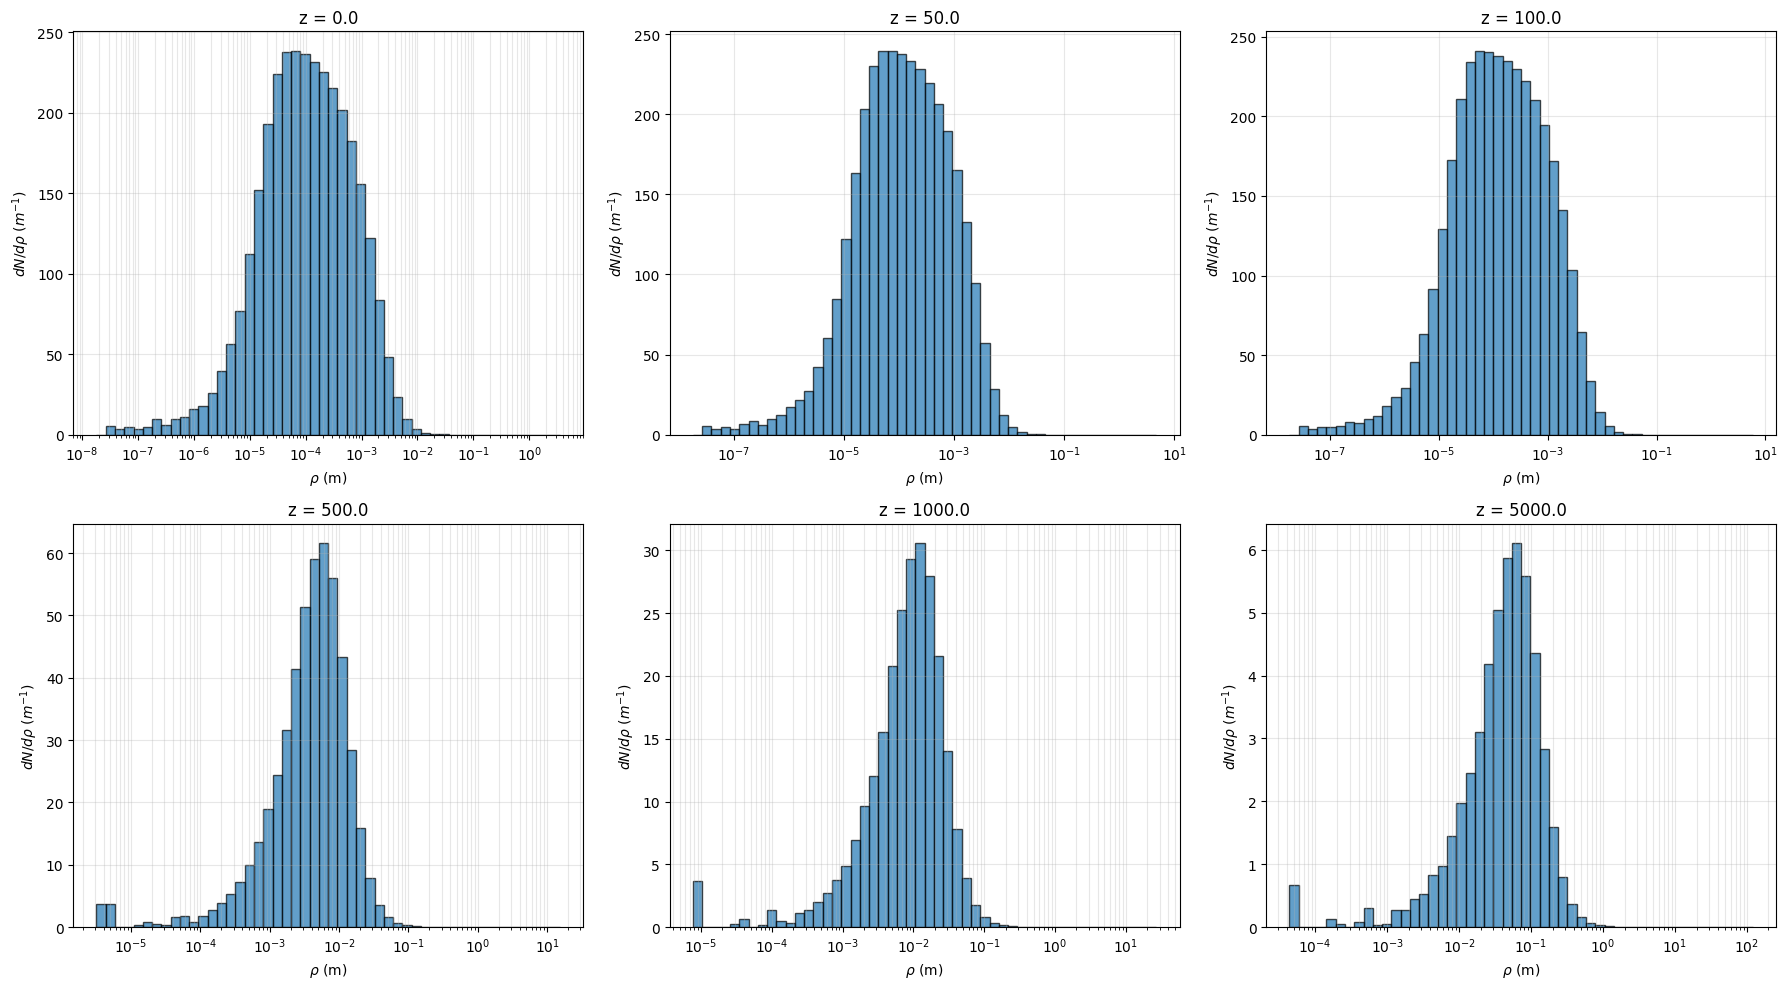

In [15]:
import matplotlib.pyplot as plt
import numpy as np

d_vals = [0.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes_flat = axes.flatten() 
weight_factor = 1 / (151.0e5)

for k in range(6):
    ax = axes_flat[k]
    data = np.array(rho[k])
    
    clean_data = data[data > 0]
    if len(clean_data) == 0:
        ax.set_title(f'd = {d_vals[k]}')
        continue

    # 1. 计算 Bin (Logspace)
    min_val = np.min(clean_data)
    max_val = np.max(clean_data)
    if min_val == max_val: min_val *= 0.9; max_val *= 1.1
    bins_log = np.logspace(np.log10(min_val), np.log10(max_val), num=51)

    # 2. 计算计数 (Delta N)
    counts, bin_edges = np.histogram(clean_data, bins=bins_log)
    
    # 3. 计算每个 bin 的宽度 (Delta rho)
    # 注意：在 logspace 下，widths 也是一个数组，且越来越大
    widths = np.diff(bin_edges)
    
    # 4. 【核心修正】计算密度 dN/drho
    # 公式：Density = (Count * Weight) / Width
    density = (counts * weight_factor) / widths

    # 5. 绘制
    # 注意：这时候画出来的高度就是 dN/drho 了
    ax.bar(bin_edges[:-1], density, width=widths, align='edge', 
           edgecolor='black', alpha=0.7)

    # 设置样式
    ax.set_xscale('log')
    #ax.set_yscale('log') # 密度通常跨度很大，建议纵轴也开 log
    
    ax.set_title(f'z = {d_vals[k]}')
    ax.set_xlabel(r'$\rho$ (m)')
    
    ax.set_ylabel(r'$dN/d\rho$ ($m^{-1}$)') 
    
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

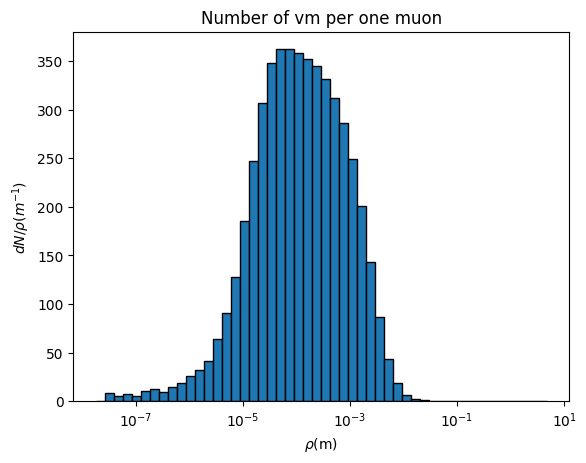

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = rho[1]  
weights_list = [1 / (151.0e5)] * len(data)

# --- 核心步骤 ---
# 1. 计算数据的最小值和最大值（如果是极小数值，用 np.min/max）
min_val = np.min(data)
max_val = np.max(data)

# 2. 使用 logspace 生成对数均匀分布的 bins
# np.log10 是取对数，比如 1e-5 变成 -5
# num=21 会生成 50 个区间
bins_log = np.logspace(np.log10(min_val), np.log10(max_val), num=51)

# 3. 将生成的 bins 传给 hist
plt.hist(data, bins=bins_log, weights=weights_list, density=True, edgecolor='black')

# 4. 设置 x 轴为对数显示
plt.xscale('log') 
# ----------------

plt.title('Number density')
plt.xlabel('$\\rho$(m)')
plt.ylabel('$dN/\\rho (m^{-1})$')
plt.show()

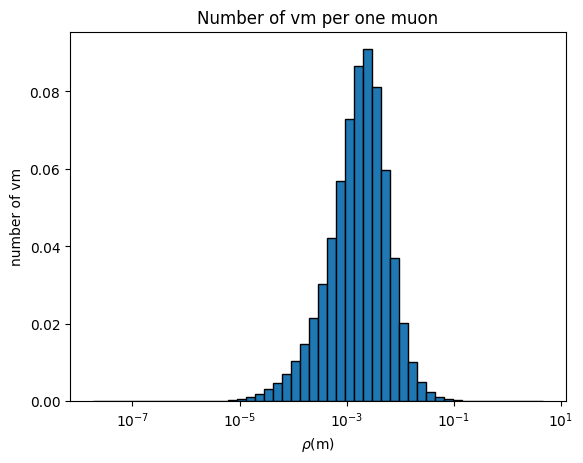

In [42]:
import matplotlib.pyplot as plt
import numpy as np

data = rho[1]  
weights_list = [1 / (151.0e5)] * len(data)

# --- 核心步骤 ---
# 1. 计算数据的最小值和最大值（如果是极小数值，用 np.min/max）
min_val = np.min(data)
max_val = np.max(data)

# 2. 使用 logspace 生成对数均匀分布的 bins
# np.log10 是取对数，比如 1e-5 变成 -5
# num=21 会生成 50 个区间
bins_log = np.logspace(np.log10(min_val), np.log10(max_val), num=51)

# 3. 将生成的 bins 传给 hist
plt.hist(data, bins=bins_log, weights=weights_list, density=False, edgecolor='black')

# 4. 设置 x 轴为对数显示
plt.xscale('log') 
# ----------------

plt.title('Number of vm per one muon')
plt.xlabel('$\\rho$(m)')
plt.ylabel('number of vm')
plt.show()

2. neutrino flux from muon decay at z=0

In [ ]:
import numpy as np

def calculate_physics_formula(theta, beta):
    """
    计算公式: sin(theta) / (2 * gamma^2 * (1 - beta * cos(theta))^2)
    其中 gamma = 1 / sqrt(1 - beta^2)
    
    参数:
    theta : float 或 numpy array, 角度 (单位：弧度 rad)
    beta  : float, 速度比 v/c (必须 0 <= beta < 1)
    
    返回:
    计算结果
    """
    # 1. 计算 Gamma
    # 注意：如果 beta >= 1，这里会报错或产生无效值
    gamma = 1 / np.sqrt(1 - beta**2)
    
    # 2. 计算主公式
    numerator = np.sin(theta)
    denominator = 2 * (gamma**2) * (1 - beta * np.cos(theta))**2
    
    return numerator / denominator

# --- 使用示例 ---
beta_val = 0.9
theta_val = np.pi / 4  # 45度，必须使用弧度

result = calculate_physics_formula(theta_val, beta_val)
print(f"计算结果: {result}")

# NumPy 的优势：可以直接输入一个角度数组
thetas = np.linspace(0, np.pi, 5) 
results = calculate_physics_formula(thetas, beta_val)
print(f"数组计算结果: {results}")

计算结果: 0.5081027543785734
数组计算结果: [0.00000000e+00 5.08102754e-01 9.50000000e-02 2.50860183e-02
 3.22275473e-18]


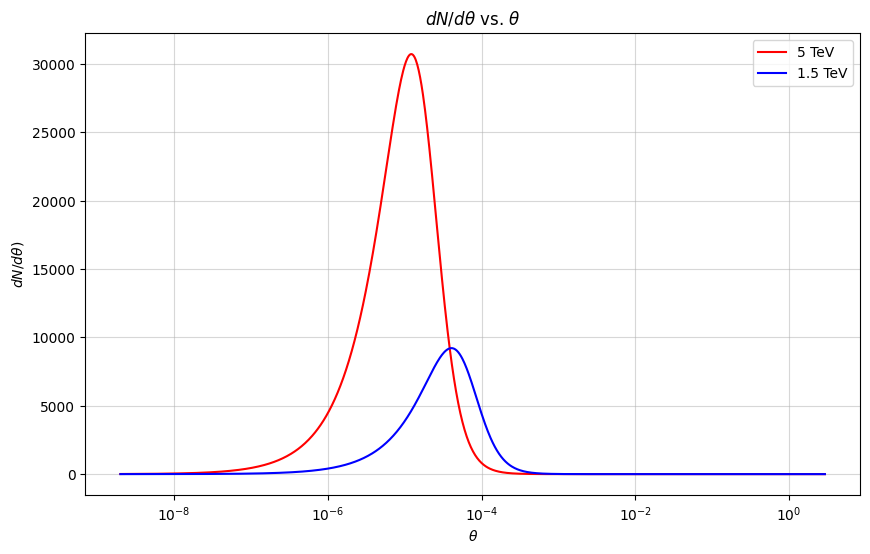

In [23]:
m_mu = 0.10566
E_mu_10TeV = 5e3
E_mu_3TeV = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeV)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeV)**2)**0.5

theta = np.geomspace(2e-9, np.pi-0.2, 1000)

dN_dtheta_10TeV = calculate_physics_formula(theta, beta10TeV)
dN_dtheta_3TeV = calculate_physics_formula(theta, beta3TeV)


plt.figure(figsize=(10, 6)) # 设置画布大小
# 绘制
plt.semilogx(theta, dN_dtheta_10TeV, label='5 TeV', color='r')
plt.semilogx(theta, dN_dtheta_3TeV, label='1.5 TeV', color='b')

# 设置标签
plt.xlabel('$\\theta$')
plt.ylabel('$dN/d\\theta)$')
plt.title('$dN/d\\theta$ vs. $\\theta$')
plt.grid(True, which="both", alpha=0.5)
plt.legend()

plt.show()

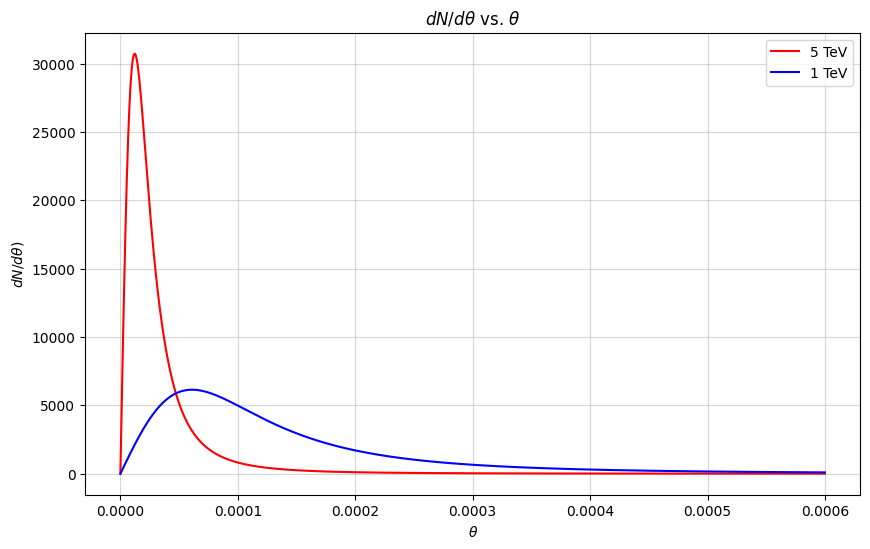

In [ ]:
m_mu = 0.10566
E_mu_10TeV = 5e3
E_mu_3TeV = 1.0e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeV)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeV)**2)**0.5

theta = np.linspace(0, 0.6e-3, 1000)

dN_dtheta_10TeV = calculate_physics_formula(theta, beta10TeV)
dN_dtheta_3TeV = calculate_physics_formula(theta, beta3TeV)


plt.figure(figsize=(10, 6)) # 设置画布大小
# 绘制
plt.plot(theta, dN_dtheta_10TeV, label='5 TeV', color='r')
plt.plot(theta, dN_dtheta_3TeV, label='1 TeV', color='b')

# 设置标签
plt.xlabel('$\\theta$')
plt.ylabel('$dN/d\\theta)$')
plt.title('$dN/d\\theta$ vs. $\\theta$')
plt.grid(True, which="both", alpha=0.5)
plt.legend()

plt.show()

2.5 neutrino flux from muon decay at z=0, but the muon's direction is not along z-axis

In [1]:
import numpy as np

def dN_dtheta_rotated(theta, beta, theta0):
    """
    计算 muon 飞行方向偏离 z 轴 theta0 时，
    中微子相对于新 z 轴的角分布 dN/dtheta; it's independent of phi0 after integration.

    参数
    ----
    theta : float or numpy array
        中微子相对于当前 z 轴的极角，单位 rad
    beta : float
        muon 的速度 beta = v/c, 要求 0 <= beta < 1
    theta0 : float
        muon 飞行方向相对于当前 z 轴的极角，单位 rad

    返回
    ----
    dN_dtheta : float or numpy array
        对 phi 积分后的角分布 dN/dtheta
    """
    gamma = 1.0 / np.sqrt(1.0 - beta**2)

    A = 1.0 - beta * np.cos(theta) * np.cos(theta0)
    B = beta * np.sin(theta) * np.sin(theta0)

    denominator = (A**2 - B**2)**(1.5)

    return np.sin(theta) / (2.0 * gamma**2) * A / denominator


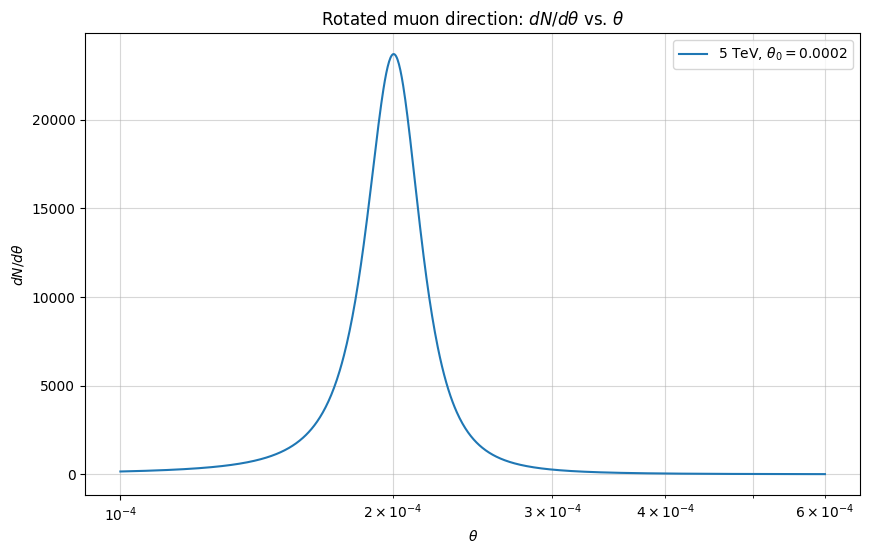

In [ ]:
m_mu = 0.10566
E_mu_10TeV = 5e3
beta10TeV = np.sqrt(1 - m_mu**2 / E_mu_10TeV**2)

theta = np.geomspace(1e-4, 0.6e-3, 1000)
theta0 = 2e-4   # 比如 muon 偏离 z 轴 2 mrad

dN_dtheta_10TeV_rot = dN_dtheta_rotated(theta, beta10TeV, theta0)


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogx(theta, dN_dtheta_10TeV_rot, label=rf'5 TeV, $\theta_0={theta0}$')
plt.xlabel('$\\theta$')
plt.ylabel('$dN/d\\theta$')
plt.title('Rotated muon direction: $dN/d\\theta$ vs. $\\theta$')
plt.grid(True, which="both", alpha=0.5)
plt.legend()
plt.show()

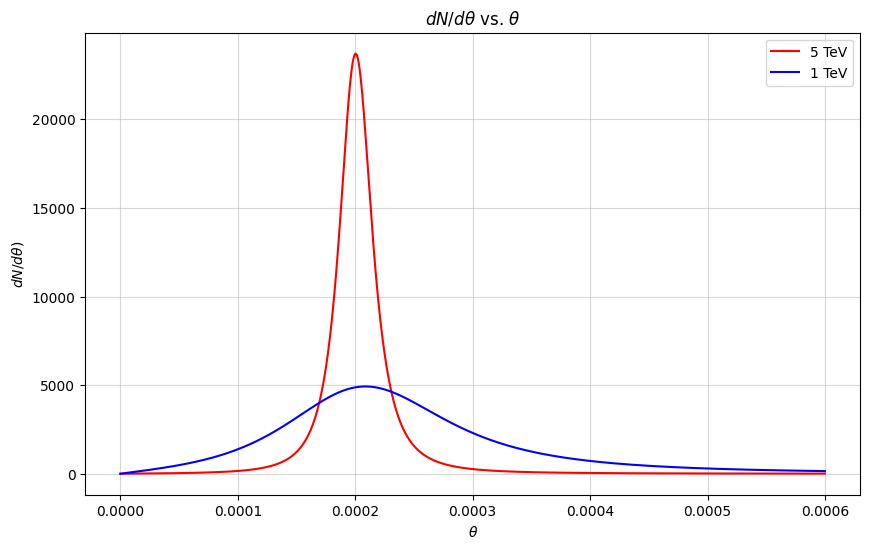

In [5]:
m_mu = 0.10566
E_mu_10TeV = 5e3
E_mu_3TeV = 1.0e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeV)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeV)**2)**0.5

theta = np.linspace(0, 0.6e-3, 1000)
theta0 = 2e-4   # 比如 muon 偏离 z 轴 2 mrad

dN_dtheta_10TeV = dN_dtheta_rotated(theta, beta10TeV, theta0)
dN_dtheta_3TeV = dN_dtheta_rotated(theta, beta3TeV, theta0)


plt.figure(figsize=(10, 6)) # 设置画布大小
# 绘制
plt.plot(theta, dN_dtheta_10TeV, label='5 TeV', color='r')
plt.plot(theta, dN_dtheta_3TeV, label='1 TeV', color='b')

# 设置标签
plt.xlabel('$\\theta$')
plt.ylabel('$dN/d\\theta)$')
plt.title('$dN/d\\theta$ vs. $\\theta$')
plt.grid(True, which="both", alpha=0.5)
plt.legend()

plt.show()

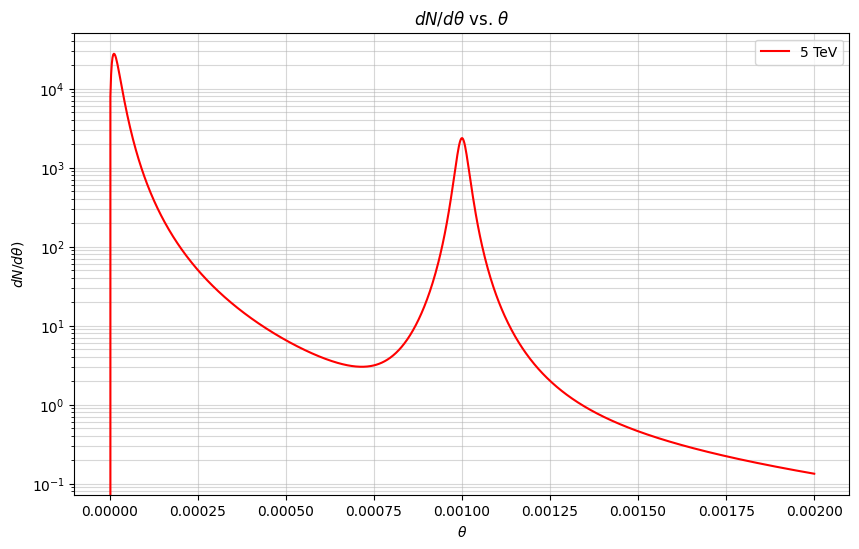

In [8]:
# consider chicane, two chicanes are total 40m, total straight length is 400m. So fraction is 10%

m_mu = 0.10566
E_mu_10TeV = 5e3
E_mu_3TeV = 1.0e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeV)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeV)**2)**0.5

theta = np.linspace(0, 2e-3, 1000)
theta0 = 1e-3   # chicane has 0.02m vertical length and 20meter horizontal length

fraction = 0.1

dN_dtheta_10TeV = dN_dtheta_rotated(theta, beta10TeV, theta0)*fraction + dN_dtheta_rotated(theta, beta10TeV, 0)*(1-fraction)
#dN_dtheta_3TeV = dN_dtheta_rotated(theta, beta3TeV, theta0)


plt.figure(figsize=(10, 6)) # 设置画布大小
# 绘制
plt.plot(theta, dN_dtheta_10TeV, label='5 TeV', color='r')
#plt.plot(theta, dN_dtheta_3TeV, label='1 TeV', color='b')

# 设置标签
plt.yscale('log')
plt.xlabel('$\\theta$')
plt.ylabel('$dN/d\\theta)$')
plt.title('$dN/d\\theta$ vs. $\\theta$')
plt.grid(True, which="both", alpha=0.5)
plt.legend()

plt.show()

2.9 including beam divergence: betax,betay~N(0,sigma_beta) -> p(theta0)=theta0/(sigma^2)*exp[-theta0^2/(2*sigma^2)] where sigma~2e-4 mrad

C:\Users\doudo\AppData\Local\Temp\ipykernel_47548\3396389887.py:39: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, err = quad(


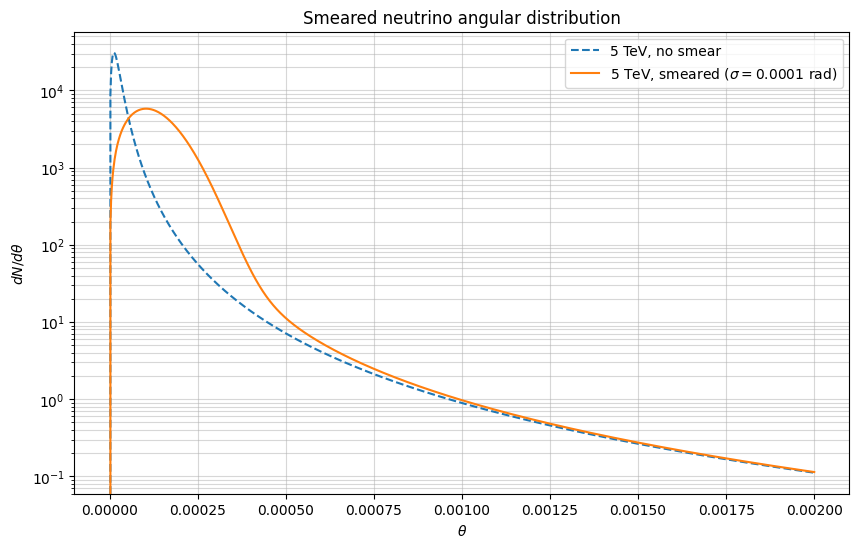

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def dN_dtheta_fixed_theta0(theta, beta, theta0, eps=1e-300):
    """
    固定 muon 偏转角 theta0 时的 dN/dtheta
    精确公式（已经对 phi 积分）
    支持 theta 为标量或 numpy array
    """
    gamma = 1.0 / np.sqrt(1.0 - beta**2)

    A = 1.0 - beta * np.cos(theta) * np.cos(theta0)
    radicand = A**2 - (beta**2) * (np.sin(theta)**2) * (np.sin(theta0)**2)
    radicand = np.maximum(radicand, eps)

    return np.sin(theta) / (2.0 * gamma**2) * A / (radicand**1.5)


def dN_dtheta_smeared_single(theta, beta, sigma,
                             n_sigma=8.0,
                             quad_epsabs=1e-10, quad_epsrel=1e-8, quad_limit=200):
    """
    对单个 theta 计算 smeared 后的 dN/dtheta:
        ∫ dtheta0 P(theta0) f(theta; theta0)

    这里把 theta0 积分截断到 [0, min(pi, n_sigma*sigma)]
    并在这个区间上重新归一化 Rayleigh 分布
    """
    theta0_max = min(np.pi, n_sigma * sigma)

    # 截断后的归一化
    norm = 1.0 - np.exp(-theta0_max**2 / (2.0 * sigma**2))

    def integrand(theta0):
        pdf = (theta0 / sigma**2) * np.exp(-theta0**2 / (2.0 * sigma**2)) / norm
        return pdf * dN_dtheta_fixed_theta0(theta, beta, theta0)

    result, err = quad(
        integrand, 0.0, theta0_max,
        epsabs=quad_epsabs,
        epsrel=quad_epsrel,
        limit=quad_limit
    )
    return result


def dN_dtheta_smeared(theta, beta, sigma,
                      n_sigma=8.0,
                      quad_epsabs=1e-10, quad_epsrel=1e-8, quad_limit=200):
    """
    支持 theta 为单个数或 numpy array
    """
    theta = np.asarray(theta)

    if theta.ndim == 0:
        return dN_dtheta_smeared_single(
            float(theta), beta, sigma,
            n_sigma=n_sigma,
            quad_epsabs=quad_epsabs,
            quad_epsrel=quad_epsrel,
            quad_limit=quad_limit
        )

    return np.array([
        dN_dtheta_smeared_single(
            th, beta, sigma,
            n_sigma=n_sigma,
            quad_epsabs=quad_epsabs,
            quad_epsrel=quad_epsrel,
            quad_limit=quad_limit
        )
        for th in theta
    ])


# -----------------------------
# 你的参数
# -----------------------------
m_mu = 0.10566
E_mu_10TeV = 5e3
E_mu_3TeV  = 1.5e3

beta10TeV = np.sqrt(1.0 - m_mu**2 / E_mu_10TeV**2)
beta3TeV  = np.sqrt(1.0 - m_mu**2 / E_mu_3TeV**2)

#theta = np.geomspace(2e-9, np.pi - 0.2, 400)

theta = np.linspace(0, 2e-3, 1000)

# 例子：beam divergence 参数 sigma（单位 rad）
sigma = 1e-4

dN_dtheta_10TeV_smear = dN_dtheta_smeared(theta, beta10TeV, sigma, n_sigma=8.0)
dN_dtheta_3TeV_smear  = dN_dtheta_smeared(theta, beta3TeV, sigma, n_sigma=8.0)

# 也可以对比未 smeared 的结果
dN_dtheta_10TeV_nosmear = dN_dtheta_fixed_theta0(theta, beta10TeV, 0.0)
dN_dtheta_3TeV_nosmear  = dN_dtheta_fixed_theta0(theta, beta3TeV, 0.0)


# -----------------------------
# 作图
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(theta, dN_dtheta_10TeV_nosmear, '--', label='5 TeV, no smear')
plt.plot(theta, dN_dtheta_10TeV_smear, '-',  label=rf'5 TeV, smeared ($\sigma={sigma}$ rad)')

#plt.plot(theta, dN_dtheta_3TeV_nosmear, '--', label='1.5 TeV, no smear')
#plt.plot(theta, dN_dtheta_3TeV_smear, '-',  label=rf'1.5 TeV, smeared ($\sigma={sigma}$ rad)')

plt.yscale('log')
plt.xlabel('$\\theta$')
plt.ylabel('$dN/d\\theta$')
plt.title('Smeared neutrino angular distribution')
plt.grid(True, which='both', alpha=0.5)
plt.legend()
plt.show()

3. neutrino flux from muon decay within the main straight line

In [2]:
# assume muon only has pz

def calculate_dNdtheta(r, theta, beta, z0):
    """
    计算 Flux 函数。
    
    参数:
    r     : 半径
    theta : 角度 (弧度制)
    beta  : 速度因子 (必须满足 |beta| < 1)
    z0    : 撞击直线长度 (不能为 0)
    
    返回:
    dNdtheta  : dN/dtheta
    """
    
    # 1. 计算中间变量 y 和 z
    # y = r * sin(theta)
    y = r * np.sin(theta)
    
    # z = r * cos(theta)
    z = r * np.cos(theta)
    
    # 安全检查：防止除以零
    # if y == 0:
    #     raise ValueError("y (r*sin(theta)) 不能为 0, 否则会导致除以零错误。")
    if z0 == 0:
        raise ValueError("z0 不能为 0。")
    if abs(beta) >= 1:
        raise ValueError("beta 的绝对值必须小于 1, 否则 gamma 为虚数或无穷大。")

    # 2. 计算 alphamax
    # alphamax = arctan((z - z0) / y)
    umax = z - z0
    umin = z + z0
    
    # 3. 计算 gamma
    gamma = 1 / np.sqrt(1 - beta**2)
    
    # 4. 计算括号内的两部分
    #below is for flux Phi, not dN/dtheta
    # termmax = (np.cos(theta)*gamma**2) * ( 1/((umax**2 + y**2)**0.5 - beta*umax) - 2*beta*gamma/y * np.arctan( gamma*( ( (umax**2+y**2)**0.5 - y )/umax - beta ) ) ) - 1/(beta*r) * (umax**2+y**2)**0.5/((umax**2+y**2)**0.5 - beta*umax)
    termmax = (np.cos(theta)*gamma**2) * ( r*y/((umax**2 + y**2)**0.5 - beta*umax) - 2*beta*gamma*r * np.arctan( gamma*( ( (umax**2+y**2)**0.5 - y )/umax - beta ) ) ) - y/beta * (umax**2+y**2)**0.5/((umax**2+y**2)**0.5 - beta*umax)
    
    # 积分下限
    #below is for flux Phi, not dN/dtheta
    # termmin = (np.cos(theta)*gamma**2) * ( 1/((umin**2 + y**2)**0.5 - beta*umin) - 2*beta*gamma/y * np.arctan( gamma*( ( (umin**2+y**2)**0.5 - y )/umin - beta ) ) ) - 1/(beta*r) * (umin**2+y**2)**0.5/((umin**2+y**2)**0.5 - beta*umin)
    #below is for dN/dtheta
    termmin = (np.cos(theta)*gamma**2) * ( r*y/((umin**2 + y**2)**0.5 - beta*umin) - 2*beta*gamma*r * np.arctan( gamma*( ( (umin**2+y**2)**0.5 - y )/umin - beta ) ) ) - y/beta * (umin**2+y**2)**0.5/((umin**2+y**2)**0.5 - beta*umin)
    
    # 5. 组合最终公式
    #below is for flux Phi, not dN/dtheta
    #prefix = 1 / (2 * z0 * 4 * np.pi * gamma**2)
    #below is for dN/dtheta
    prefix = 2*np.pi / (2 * z0 * 4 * np.pi * gamma**2)

    dNdtheta = prefix * (termmax - termmin)
    
    return dNdtheta

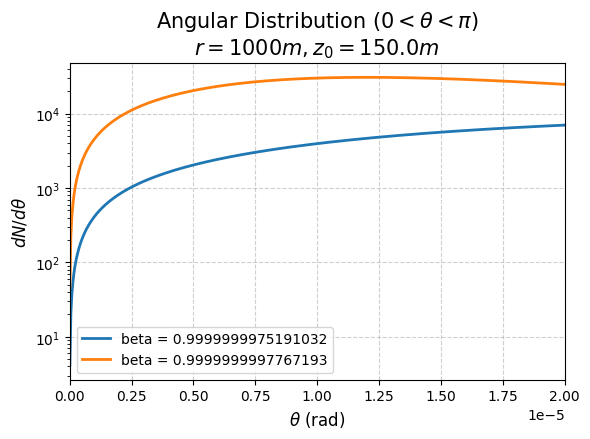

In [12]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
# --- 1. 设置固定参数 ---
r_val = 1000
z0_val = 150.0

x_max = 2.0e-5
# --- 2. 设置 Theta 范围 (0 到 pi) ---
# 避开 0 和 pi，防止 1/sin(theta) 除以零
epsilon = 1e-8  # 偏移量，越小越接近端点，但数值会越大
theta_vals = np.linspace(epsilon, x_max, 500)

# --- 3. 绘图 ---
plt.figure(figsize=(6, 4.5))

# 我们画几条不同 beta 的线来对比
beta_list = [beta3TeV, beta10TeV]

for b in beta_list:
    if b == beta3TeV:
        b = beta3TeV
        #continue
    flux_vals = calculate_dNdtheta(r_val, theta_vals, b, z0_val)
    plt.plot(theta_vals, flux_vals, label=f'beta = {b}', linewidth=2)


#plt.yscale('log')
# --- 4. 格式化图表 ---
plt.title(rf"Angular Distribution ($0 < \theta < \pi$)" + "\n" + rf"$r={r_val}m, z_0={z0_val}m$", fontsize=15)
plt.xlabel("$\\theta$ (rad)", fontsize=12)
plt.ylabel("$dN/d\\theta$", fontsize=12)

# 设置 X 轴刻度为 pi 的倍数
# plt.xticks(
#     [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
#     ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
# )

# 限制 Y 轴范围 (可选)
# 因为端点发散，不限制 Y 轴可能导致中间细节看不清
# 这里我们动态获取中间部分的最大值来设置上限

plt.yscale('log')
#plt.ylim(1e-10, 1e2) 
plt.xlim(0.0, x_max) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

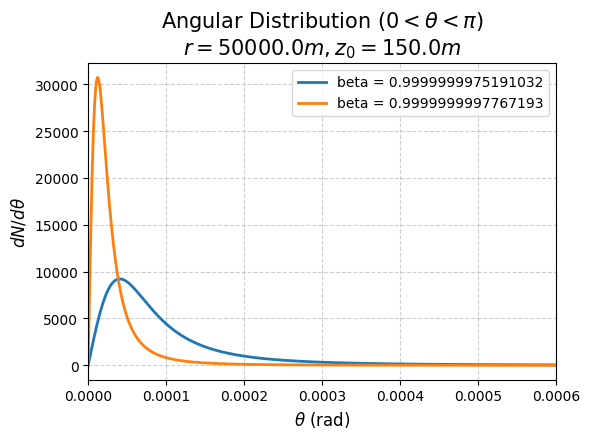

In [4]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
# --- 1. 设置固定参数 ---
r_val = 50e3
z0_val = 150.0

# --- 2. 设置 Theta 范围 (0 到 pi) ---
# 避开 0 和 pi，防止 1/sin(theta) 除以零
epsilon = 0.0  # 偏移量，越小越接近端点，但数值会越大
theta_vals = np.linspace(epsilon, 6e-4, 500)

# --- 3. 绘图 ---
plt.figure(figsize=(6, 4.5))

# 我们画几条不同 beta 的线来对比
beta_list = [beta3TeV, beta10TeV]

for b in beta_list:
    flux_vals = calculate_dNdtheta(r_val, theta_vals, b, z0_val)
    plt.plot(theta_vals, flux_vals, label=f'beta = {b}', linewidth=2)


#plt.yscale('log')
# --- 4. 格式化图表 ---
plt.title(rf"Angular Distribution ($0 < \theta < \pi$)" + "\n" + rf"$r={r_val}m, z_0={z0_val}m$", fontsize=15)
plt.xlabel("$\\theta$ (rad)", fontsize=12)
plt.ylabel("$dN/d\\theta$", fontsize=12)

# 设置 X 轴刻度为 pi 的倍数
# plt.xticks(
#     [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
#     ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
# )

# 限制 Y 轴范围 (可选)
# 因为端点发散，不限制 Y 轴可能导致中间细节看不清
# 这里我们动态获取中间部分的最大值来设置上限

#plt.ylim(1e-10, 1e2) 
plt.xlim(0.0, 6.0e-4) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

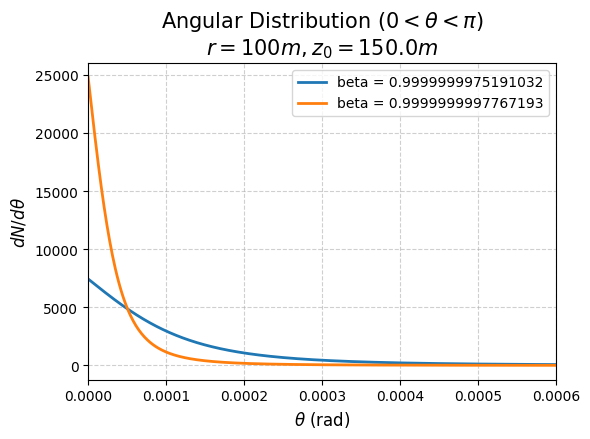

In [32]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
# --- 1. 设置固定参数 ---
r_val = 100
z0_val = 150.0

# --- 2. 设置 Theta 范围 (0 到 pi) ---
# 避开 0 和 pi，防止 1/sin(theta) 除以零
epsilon = 0.0  # 偏移量，越小越接近端点，但数值会越大
theta_vals = np.linspace(epsilon, 6e-4, 500)

# --- 3. 绘图 ---
plt.figure(figsize=(6, 4.5))

# 我们画几条不同 beta 的线来对比
beta_list = [beta3TeV, beta10TeV]

for b in beta_list:
    flux_vals = calculate_dNdtheta(r_val, theta_vals, b, z0_val)
    plt.plot(theta_vals, flux_vals, label=f'beta = {b}', linewidth=2)


#plt.yscale('log')
# --- 4. 格式化图表 ---
plt.title(rf"Angular Distribution ($0 < \theta < \pi$)" + "\n" + rf"$r={r_val}m, z_0={z0_val}m$", fontsize=15)
plt.xlabel("$\\theta$ (rad)", fontsize=12)
plt.ylabel("$dN/d\\theta$", fontsize=12)

# 设置 X 轴刻度为 pi 的倍数
# plt.xticks(
#     [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
#     ['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
# )

# 限制 Y 轴范围 (可选)
# 因为端点发散，不限制 Y 轴可能导致中间细节看不清
# 这里我们动态获取中间部分的最大值来设置上限

#plt.ylim(1e-10, 1e2) 
plt.xlim(0.0, 6.0e-4) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

4. neutrino flux for 2D distribution (no beam divergence), dN/dtheta/dE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_muon_decay_distribution(beta=0.9):
    """
    绘制实验室系下 Muon 衰变的能量-角度二维分布图。
    
    参数:
    beta: float, Muon 沿 +z 轴的速度 (v/c)
    """
    
    # 1. 基础物理常数计算
    gamma = 1.0 / np.sqrt(1 - beta**2)
    print(f"设定参数: Beta = {beta}, Gamma = {gamma:.4f}")
    
    # 2. 准备网格数据
    # cos(theta) 从 -1 到 1
    costheta_vals = np.linspace(-1, 1, 400)
    
    # x = 2E/m_mu。
    # 在实验室系，最大能量发生在 theta=0 处，x_max = 1 / (gamma * (1 - beta))
    # 我们把绘图范围设定得比最大值稍微大一点，以便看清边界
    x_limit_global = 1.0 / (gamma * (1 - beta))
    x_vals = np.linspace(0, x_limit_global * 1.1, 400)
    
    # 创建网格 (X轴: 角度, Y轴: 能量)
    CosTheta, X = np.meshgrid(costheta_vals, x_vals)
    
    # 3. 计算中间变量 x' (静止系中的归一化能量)
    # 公式: x' = gamma * x * (1 - beta * cos_theta)
    X_prime = gamma * X * (1 - beta * CosTheta)
    
    SinTheta = (1-CosTheta**2)**0.5
    # 4. 计算分布函数 (忽略常数系数 G_F等，只看形状)
    # 公式: f ~ gamma * x^2 * (1 - beta * cos_theta) * (3 - 2 * x')
    # 注意：我们 derived 的公式里已经包含 Jacobian
    distribution = gamma * (X**2) * (1 - beta * CosTheta) * (3 - 2 * X_prime) * SinTheta # sinTheta for convert dcostheta to dtheta
    
    # 5. 处理物理边界 (Masking)
    # 物理限制: 0 <= x' <= 1
    # 如果 x' > 1，说明违反能量守恒（超出了Muon静止质量），概率为0
    mask = (X_prime >= 0) & (X_prime <= 1)
    
    # 将非物理区域的值设为 NaN (绘图时透明) 或 0
    distribution_masked = np.where(mask, distribution, np.nan)

    # 6. 计算运动学边界曲线 (用于画那条临界线)
    # x_boundary = 1 / (gamma * (1 - beta * cos_theta))
    boundary_line = 1.0 / (gamma * (1 - beta * costheta_vals))

    # --- 开始绘图 ---
    plt.figure(figsize=(8, 6))
    
    # 绘制热力图 (pcolormesh)
    mesh = plt.pcolormesh(CosTheta, X, distribution_masked, 
                          cmap='jet', shading='auto')
    
    # 添加颜色条
    cbar = plt.colorbar(mesh)
    cbar.set_label("Probability Density (Arbitrary Units)", fontsize=12)
    
    # 绘制运动学边界线 (黑色虚线)
    plt.plot(costheta_vals, boundary_line, 'k--', linewidth=2, label='Kinematic Boundary ($x\'=1$)')
    
    # 图表装饰
    plt.title(f'Muon Decay Distribution in Lab Frame ($\\beta={beta}$)', fontsize=16)
    plt.xlabel('$\\cos(\\theta)$ (Lab Angle relative to Muon velocity)', fontsize=14)
    plt.ylabel('$x = 2E/m_\\mu$ (Normalized Lab Energy)', fontsize=14)
    plt.ylim(0, x_limit_global * 1.1)
    plt.xlim(-1, 1)
    
    # 添加辅助说明文本
    plt.text(0.5, x_limit_global*0.8, 'Forward Boost\n(Blue Shift)', 
             color='white', ha='center', fontweight='bold')
    plt.text(-0.5, x_limit_global*0.1, 'Backward\n(Red Shift)', 
             color='black', ha='center', fontweight='bold')

    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# 运行脚本
# if __name__ == "__main__":
    # plot_muon_decay_distribution(beta=0.9)

设定参数: Beta = 0.9999999997767193, Gamma = 47321.5960


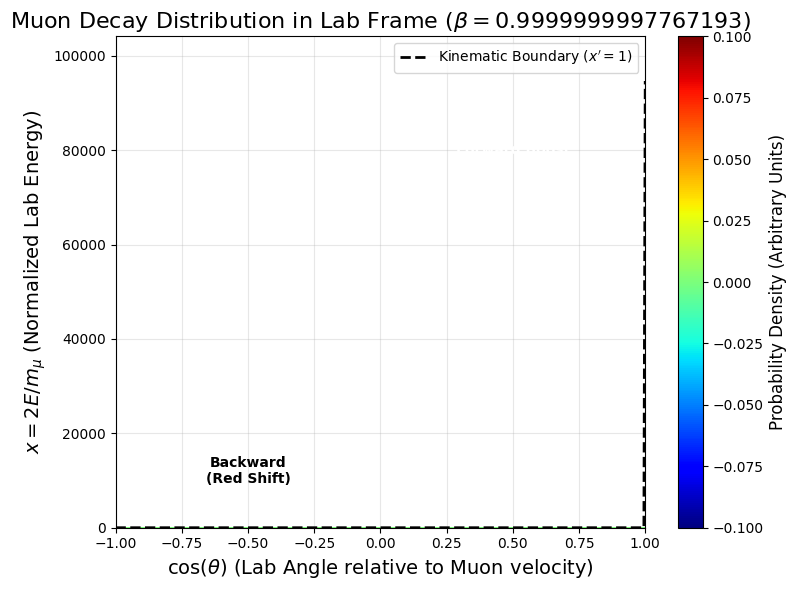

In [33]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
plot_muon_decay_distribution(beta=beta10TeV)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_muon_decay_theta_distribution(beta=0.9):
    """
    绘制 dN / (dx dTheta) 分布。
    """
    
    # 1. 基础常数
    gamma = 1.0 / np.sqrt(1 - beta**2)
    print(f"Beta = {beta}, Gamma = {gamma:.4f}")
    
    x_upper_limit = 6e-4
    # 2. 准备网格
    theta_vals = np.linspace(0, x_upper_limit, 400) 
    x_limit_global = 1.0 / (gamma * (1 - beta))
    x_vals = np.linspace(0, x_limit_global * 1.1, 400)
    
    Theta, X = np.meshgrid(theta_vals, x_vals)
    
    CosTheta = np.cos(Theta)
    SinTheta = np.sin(Theta)
    
    # 3. x'（静止系能量）
    X_prime = gamma * X * (1 - beta * CosTheta)
    
    # 4. 分布函数
    distribution_cos = gamma * (X**2) * (1 - beta * CosTheta) * (3 - 2 * X_prime)
    distribution_theta = distribution_cos * SinTheta
    
    # 5. 物理边界
    mask = (X_prime >= 0) & (X_prime <= 1)
    distribution_masked = np.where(mask, distribution_theta, np.nan)
    
    # 6. 运动学边界
    boundary_line = 1.0 / (gamma * (1 - beta * np.cos(theta_vals)))

    # ======================
    # 画图（关键修改在这里）
    # ======================
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    mesh = ax.pcolormesh(
        Theta, X, distribution_masked,
        cmap='jet', shading='auto'
    )
    
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(r"$\frac{d^2N}{dx\, d\theta}$", fontsize=14)
    
    ax.plot(theta_vals, boundary_line, 'k--', lw=2, label='Kinematic Boundary')
    
    ax.set_title(
        rf"Muon Decay: $dN/(dx\,d\theta)$ (10 TeV MuC)",
        fontsize=16
    )
    ax.set_xlabel("$\\theta$ (Lab Angle)", fontsize=14)
    ax.set_ylabel("$x = 2E/m_\\mu$ (Normalized Energy)", fontsize=14)
    
    ax.set_xlim(0, x_upper_limit)
    ax.set_ylim(0, x_limit_global * 1.1)
    
    # ax.text(
    #     0.1, 0.55,
    #     r"$\sin\theta \to 0$",
    #     transform=ax.transAxes,
    #     color='white',
    #     fontsize=11
    # )
    
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    
    plt.show()


#plot_muon_decay_theta_distribution(beta=0.9)


Beta = 0.9999999997767193, Gamma = 47321.5960


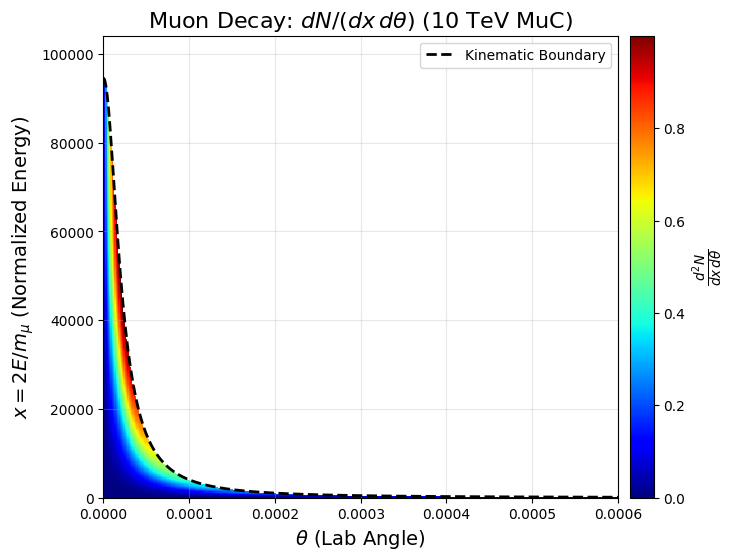

In [41]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
plot_muon_decay_theta_distribution(beta=beta10TeV)

------------------------------
Beta = 1.00000000
Gamma = 47321.5960
Theta Max set to: 0.000634 rad (approx 1.0 * 1/gamma)
Total Integrated Probability: 0.999097
------------------------------


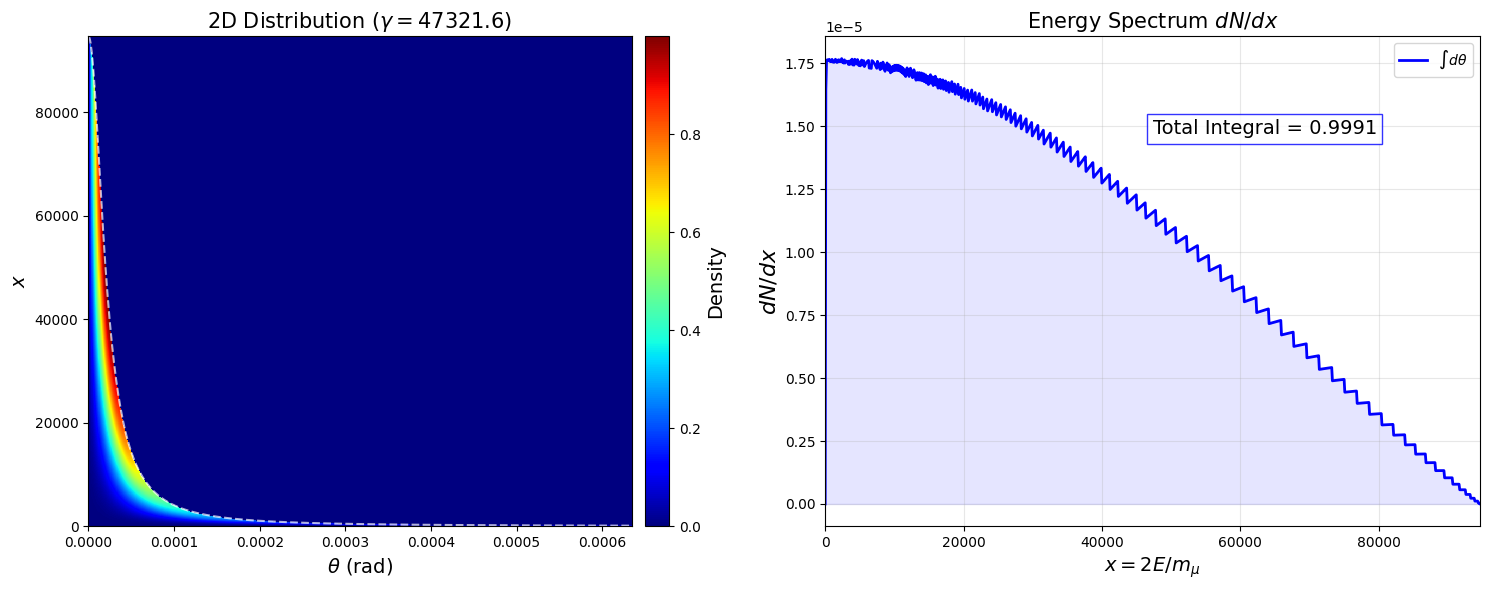

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_muon_decay_check_normalization(beta=0.9, theta_max=None):
    """
    beta: 速度
    theta_max: 绘图和积分的最大角度。如果不传，自动根据 gamma 估算。
    """
    
    # --- 1. 物理计算 ---
    gamma = 1.0 / np.sqrt(1 - beta**2)
    print(f"-"*30)
    print(f"Beta = {beta:.8f}")
    print(f"Gamma = {gamma:.4f}")
    
    # 自动设定 theta 范围：
    # 对于高能粒子，几乎所有东西都在 10/gamma 角度以内。
    # 为了积分准确，我们取 50/gamma 左右的范围，确保捕捉到尾巴。
    if theta_max is None:
        theta_max = 30.0 / gamma 
        # 如果计算出来超过 Pi (比如低速情况), 截断到 Pi
        if theta_max > np.pi: theta_max = np.pi

    print(f"Theta Max set to: {theta_max:.6f} rad (approx {30.0/gamma/theta_max:.1f} * 1/gamma)")

    # 准备网格
    # 注意：为了积分准确，网格点数对于高能情况很重要
    theta_vals = np.linspace(0, theta_max, 1000) 
    
    x_limit_global = 1.0 / (gamma * (1 - beta))
    x_vals = np.linspace(0, x_limit_global * 1.05, 1000)
    
    Theta, X = np.meshgrid(theta_vals, x_vals)
    
    # 计算中间变量
    CosTheta = np.cos(Theta)
    SinTheta = np.sin(Theta)
    X_prime = gamma * X * (1 - beta * CosTheta)
    
    # 分布函数
    distribution_cos = gamma * (X**2) * (1 - beta * CosTheta) * (3 - 2 * X_prime)
    distribution_theta = distribution_cos * SinTheta
    
    # Mask
    mask = (X_prime >= 0) & (X_prime <= 1)
    distribution_masked = np.where(mask, distribution_theta, 0.0) # 用0填充以便积分

    # --- 2. 积分计算 ---
    
    # 第一步：对 Theta 积分，得到 dN/dx
    # 使用 trapezoid (numpy新版) 或 trapz (旧版)
    try:
        dN_dx = np.trapezoid(distribution_masked, theta_vals, axis=1)
    except AttributeError:
        dN_dx = np.trapezoid(distribution_masked, theta_vals, axis=1)

    # ==========================================
    # 第二步：对 x 积分，得到 Total Probability
    # ==========================================
    try:
        total_prob = np.trapezoid(dN_dx, x_vals)
    except AttributeError:
        total_prob = np.trapezoid(dN_dx, x_vals)

    print(f"Total Integrated Probability: {total_prob:.6f}")
    print(f"-"*30)

    # ======================
    # 画图
    # ======================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- 左图：2D ---
    # 为了看清，左图稍微限制一下显示的高度，因为高能时x非常大
    mesh = ax1.pcolormesh(Theta, X, distribution_masked, cmap='jet', shading='auto')
    cbar = fig.colorbar(mesh, ax=ax1, pad=0.02)
    cbar.set_label(r"Density", fontsize=14)
    
    boundary_line = 1.0 / (gamma * (1 - beta * np.cos(theta_vals)))
    ax1.plot(theta_vals, boundary_line, 'w--', lw=1.5, alpha=0.7, label='Kinematic Boundary')
    
    ax1.set_title(f"2D Distribution ($\\gamma={gamma:.1f}$)", fontsize=15)
    ax1.set_xlabel(r"$\theta$ (rad)", fontsize=14)
    ax1.set_ylabel(r"$x$", fontsize=14)
    ax1.set_ylim(0, x_limit_global)
    
    # --- 右图：1D dN/dx ---
    ax2.plot(x_vals, dN_dx, 'b-', lw=2, label=r'$\int d\theta$')
    ax2.fill_between(x_vals, 0, dN_dx, color='blue', alpha=0.1)
    
    # 在图中显示积分结果
    ax2.text(0.5, 0.8, f"Total Integral = {total_prob:.4f}", 
             transform=ax2.transAxes, fontsize=14, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'))

    ax2.set_title(r"Energy Spectrum $dN/dx$", fontsize=15)
    ax2.set_xlabel(r"$x = 2E/m_\mu$", fontsize=14)
    ax2.set_ylabel(r"$dN/dx$", fontsize=16)
    ax2.set_xlim(0, x_limit_global)
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# --- 参数设置 ---
m_mu = 0.10566
E_mu_10TeV = 5e3  # 5000 GeV (Assuming 10TeV collider means beam energy or total CoM?) 
# 假设 E_mu 是 Muon 能量 5000 GeV
beta10TeV = np.sqrt(1 - (m_mu / E_mu_10TeV)**2)

# 运行验证
# 注意：我没有手动传 theta范围，让函数根据 Gamma 自动计算最佳范围
plot_muon_decay_check_normalization(beta=beta10TeV)

5. neutrino flux for 2D distribution (with beam divergence), dN/dtheta/dE

In [1]:
# single-core run
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# 1. 物理模型部分 (Rest Frame Spectra & PDF)
# =============================================================================

def f_rest(xp, kind="nu_mu"):
    """
    静止系光谱 f(x').
    xp = 2E'/m_mu (muon rest frame), range [0,1].
    kind: "nu_mu" or "nubar_e"
    """
    if kind == "nu_mu":
        return 2.0 * xp**2 * (3.0 - 2.0 * xp)
    elif kind == "nubar_e":
        return 12.0 * xp**2 * (1.0 - xp)
    else:
        raise ValueError("kind must be 'nu_mu' or 'nubar_e'")

def rayleigh_pdf(betaT, sigma):
    """瑞利分布 PDF，用于横向速度 betaT 的分布"""
    return (betaT / sigma**2) * np.exp(-betaT**2 / (2.0 * sigma**2))

# =============================================================================
# 2. 核心计算部分 (Lorentz Boost & Integration)
# =============================================================================

def compute_d2N_dx_dtheta_full(
    beta=0.999999,                  # Muon total speed
    theta_max=6e-4,                 # Max lab angle to scan
    n_theta=250,
    n_x=350,
    n_phi=720,
    kind="nu_mu",
    # betaT options:
    average_betaT=True,             # Integrate over Rayleigh betaT
    sigma_betaT=2e-4,
    n_betaT=25,
    betaT_max_factor=6.0,
    betaT_fixed=None,
):
    """
    计算 d^2N / (dx dtheta).
    返回: theta_vals, x_vals, dist (counts distribution), gamma
    """

    if not (0.0 < beta < 1.0):
        raise ValueError("beta must be in (0,1).")

    gamma = 1.0 / np.sqrt(1.0 - beta**2)

    # 1. 网格设置
    theta_vals = np.linspace(0.0, theta_max, n_theta)
    
    # x grid: max energy ~ gamma(1+beta) => x_max ~ 1/(gamma(1-beta))
    x_max_global = 1.0 / (gamma * (1.0 - beta))
    x_vals = np.linspace(0.0, x_max_global * 1.05, n_x)

    phi_vals = np.linspace(0.0, 2.0*np.pi, n_phi, endpoint=False)
    cosphi = np.cos(phi_vals)
    dphi = 2.0*np.pi / n_phi

    # 2. BetaT 网格与权重处理
    if average_betaT:
        if sigma_betaT <= 0:
            betaT_grid = np.array([0.0])
            w_betaT = np.array([1.0])
        else:
            betaT_max = min(beta * (1.0 - 1e-12), betaT_max_factor * sigma_betaT)
            betaT_grid = np.linspace(0.0, betaT_max, n_betaT)
            pdf = rayleigh_pdf(betaT_grid, sigma_betaT)
            
            # 归一化 PDF
            norm = np.trapezoid(pdf, betaT_grid)
            if norm == 0.0:
                betaT_grid = np.array([0.0]); w_betaT = np.array([1.0])
            else:
                w_betaT = pdf / norm  # 这里保留 pdf 值，后续用 trapezoid 积分
    else:
        # 固定 betaT 模式
        if betaT_fixed is None:
            betaT_fixed = np.sqrt(2.0) * sigma_betaT # Default to RMS
        betaT_fixed = min(betaT_fixed, beta*(1.0-1e-12))
        betaT_grid = np.array([betaT_fixed])
        w_betaT = np.array([1.0])

    # 纵向速度 betaz (能量守恒约束)
    betaz_grid = np.sqrt(np.maximum(beta**2 - betaT_grid**2, 0.0))

    # 3. 主循环计算
    dist = np.zeros((n_x, n_theta), dtype=float)

    for j, th in enumerate(theta_vals):
        sth = np.sin(th)
        cth = np.cos(th)

        # A = 1 - beta * cos(theta_lab_frame_angle)
        # 考虑 betaT 的修正: beta * n = betaz*cos(th) + betaT*sin(th)*cos(phi)
        A = 1.0 - betaz_grid[:, None] * cth - betaT_grid[:, None] * sth * cosphi[None, :] 
        
        # x' = gamma * x * A
        xp = gamma * x_vals[None, None, :] * A[:, :, None]

        # 物理截断: 0 <= x' <= 1
        mask = (xp >= 0.0) & (xp <= 1.0) & (A[:, :, None] > 0.0)

        # 被积函数: f(x') / A
        integrand = np.where(mask, f_rest(xp, kind=kind) / A[:, :, None], 0.0)

        # 对 phi 积分
        I_phi = integrand.sum(axis=1) * dphi

        # 对 betaT 平均/积分
        if average_betaT and betaT_grid.size > 1:
            I_betaT = np.trapezoid(I_phi * w_betaT[:, None], betaT_grid, axis=0)
        else:
            I_betaT = I_phi[0, :]

        # 雅可比与几何因子: d^2N / (dx dtheta)
        # 因子 sth 来自 dOmega -> dtheta
        dist[:, j] = (sth / (4.0 * np.pi * gamma)) * I_betaT

    return theta_vals, x_vals, dist, gamma

# =============================================================================
# 3. 绘图与可视化部分 (包含 Flux 视图)
# =============================================================================

def plot_muon_decay_comprehensive(
    beta=0.999999,
    sigma_betaT=2e-4,
    theta_max=6e-4,
    kind="nu_mu",
    average_betaT=True,
    n_theta=250,
    n_x=350,
    n_phi=720,
    n_betaT=25,
):
    print(f"Start calculation for {kind} with beta={beta}...")
    theta_vals, x_vals, dist, gamma = compute_d2N_dx_dtheta_full(
        beta=beta,
        theta_max=theta_max,
        n_theta=n_theta,
        n_x=n_x,
        n_phi=n_phi,
        kind=kind,
        average_betaT=average_betaT,
        sigma_betaT=sigma_betaT,
        n_betaT=n_betaT,
    )
    print("Calculation done. Plotting...")

    # --- 1. 数据处理 ---
    
    # A. 计算 Flux (物理通量 d^2N/dxdOmega)
    with np.errstate(divide='ignore', invalid='ignore'):
        flux = dist / np.sin(theta_vals)[None, :]
    # 修正 theta=0 处 (利用邻近插值)
    if theta_vals[0] == 0.0:
        flux[:, 0] = flux[:, 1]

    # B. 计算 1D 分布
    # 对 theta 积分得到 dN/dx (能量谱)
    dNdx = np.trapezoid(dist, theta_vals, axis=1)
    
    # [新增] 对 x 积分得到 dN/dtheta (角度分布)
    dNdtheta = np.trapezoid(dist, x_vals, axis=0)

    # 网格化用于 2D 绘图
    Theta, X = np.meshgrid(theta_vals, x_vals)
    
    # 理论边界参考 (betaT=0)
    boundary_ref = 1.0 / (gamma * (1.0 - beta * np.cos(theta_vals)))

    # --- 2. 绘图 (改为 2x2 布局) ---
    fig = plt.figure(figsize=(16, 12))
    
    # --- 左上图：d^2N / (dx dtheta) [计数分布] ---
    ax1 = fig.add_subplot(2, 2, 1)
    mesh1 = ax1.pcolormesh(Theta, X, dist, shading="auto", cmap="jet")
    fig.colorbar(mesh1, ax=ax1, label=r"Intensity (arb.)")
    ax1.plot(theta_vals, boundary_ref, "w--", lw=1.5, alpha=0.7, label="Limit")
    ax1.set_title(r"(A) Counts: $\frac{d^2N}{dx\,d\theta}$ (Includes $\sin\theta$)", fontsize=13)
    ax1.set_xlabel(r"$\theta$ (rad)")
    ax1.set_ylabel(r"$x_{lab} = 2E/m_\mu$")
    ax1.set_ylim(0, x_vals.max())
    ax1.legend(loc="upper right", frameon=False, labelcolor='white')

    # --- 右上图：d^2N / (dx dOmega) [物理通量] ---
    ax2 = fig.add_subplot(2, 2, 2)
    mesh2 = ax2.pcolormesh(Theta, X, flux, shading="auto", cmap="inferno") 
    fig.colorbar(mesh2, ax=ax2, label=r"Flux / sr")
    ax2.plot(theta_vals, boundary_ref, "w--", lw=1.5, alpha=0.7)
    ax2.set_title(r"(B) Flux: $\frac{d^2N}{dx\,d\Omega}$ (Physical Intensity)", fontsize=13)
    ax2.set_xlabel(r"$\theta$ (rad)")
    ax2.set_ylabel(r"$x_{lab}$")
    ax2.set_ylim(0, x_vals.max())

    # --- [新增] 左下图：dN/dtheta (角度分布) ---
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(theta_vals, dNdtheta, lw=2, color='darkred')
    ax3.set_title(r"(C) Angular Dist: $\frac{dN}{d\theta}$ (Integrated over $x$)", fontsize=13)
    ax3.set_xlabel(r"$\theta$ (rad)", fontsize=12)
    ax3.set_ylabel(r"$\frac{dN}{d\theta}$ (Counts / rad)", fontsize=12)
    ax3.set_xlim(0, theta_vals.max())
    ax3.grid(True, alpha=0.3)
    # 添加说明
    ax3.text(0.5, 0.5, "Goes to 0 at $\\theta=0$\nbecause Area $\\propto \\sin\\theta$", 
             transform=ax3.transAxes, ha='center', fontsize=10, color='gray')

    # --- 右下图：dN/dx (能量谱) ---
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(x_vals, dNdx, lw=2, color='navy')
    ax4.set_title(r"(D) Energy Spectrum: $\frac{dN}{dx}$ (Integrated over $\theta$)", fontsize=13)
    ax4.set_xlabel(r"$x_{lab} = 2E/m_\mu$", fontsize=12)
    ax4.set_ylabel("Intensity", fontsize=12)
    ax4.set_xlim(0, x_vals.max())
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. 运行示例
# =============================================================================

# if __name__ == "__main__":
#     # 参数说明:
#     # beta: 0.999999 (gamma ~ 707)
#     # sigma_betaT: 光束发散角相关参数
#     # theta_max: 绘图范围，通常取几倍的 1/gamma (这里 1/707 ~ 0.0014)
    
#     plot_muon_decay_comprehensive(
#         beta=0.999999, 
#         sigma_betaT=2e-4, 
#         theta_max=1.5e-3,  # 稍微调大了范围以便看清全貌
#         kind="nu_mu",      # 改为 "nubar_e" 可看另一种中微子
#         average_betaT=True,
#         n_theta=200, 
#         n_x=300
#     )

In [ ]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
plot_muon_decay_comprehensive(beta=beta10TeV, sigma_betaT=2e-4, theta_max=1.5e-3, kind="nu_mu",
                average_betaT=True, n_theta=1000, n_x=1000, n_phi=720, n_betaT=300)

In [3]:
# multi-core run
import numpy as np
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed, cpu_count

# =============================================================================
# 1. 基础物理函数 (保持不变)
# =============================================================================

def f_rest(xp, kind="nu_mu"):
    if kind == "nu_mu":
        return 2.0 * xp**2 * (3.0 - 2.0 * xp)
    elif kind == "nubar_e":
        return 12.0 * xp**2 * (1.0 - xp)
    else:
        raise ValueError("kind must be 'nu_mu' or 'nubar_e'")

def rayleigh_pdf(betaT, sigma):
    return (betaT / sigma**2) * np.exp(-betaT**2 / (2.0 * sigma**2))

# =============================================================================
# 2. 并行计算核心 Worker
# =============================================================================

def calculate_chunk(theta_chunk, x_vals, beta, gamma, kind, 
                    betaT_grid, betaz_grid, w_betaT, 
                    cosphi, dphi, average_betaT):
    """
    这是一个 Worker 函数，负责计算分配给它的那一小部分 theta 的结果。
    """
    n_x = len(x_vals)
    n_theta_chunk = len(theta_chunk)
    
    # 结果容器：(n_x, n_theta_chunk)
    dist_chunk = np.zeros((n_x, n_theta_chunk), dtype=float)
    
    # 在这个 chunk 内循环
    for j, th in enumerate(theta_chunk):
        sth = np.sin(th)
        cth = np.cos(th)

        # -----------------------------------------------------------
        # 这里的逻辑和之前完全一样，只是为了性能我们尽量利用矩阵化
        # -----------------------------------------------------------
        
        # A shape: (n_betaT, n_phi)
        A = 1.0 - betaz_grid[:, None] * cth - betaT_grid[:, None] * sth * cosphi[None, :]
        
        # 初始化这个 theta 的累积结果
        I_betaT_val = np.zeros(n_x) 

        # 对 betaT 进行循环 (为了节省内存，不一次性生成 4D 数组)
        for ib, bT in enumerate(betaT_grid):
            # A_slice: (n_phi,)
            A_slice = A[ib, :]
            
            # xp: (n_phi, n_x) -> Broadcasting
            xp = gamma * x_vals[None, :] * A_slice[:, None]
            
            mask = (xp >= 0.0) & (xp <= 1.0) & (A_slice[:, None] > 0.0)
            
            # integrand: (n_phi, n_x)
            val = np.where(mask, f_rest(xp, kind=kind) / A_slice[:, None], 0.0)
            
            # 对 Phi 积分 -> (n_x,)
            val_phi = val.sum(axis=0) * dphi
            
            # 累加到 betaT 积分中 (带权重)
            I_betaT_val += val_phi * w_betaT[ib]

        # 最终归一化 betaT 积分 (如果使用 trapezoid 规则)
        if average_betaT and len(betaT_grid) > 1:
            # 注意：这里的 w_betaT 已经是 pdf 值，如果仅仅是 sum，我们需要乘步长
            # 但我们在主函数里归一化处理比较麻烦，这里简化为：
            # 假设 w_betaT 已经是 (pdf / sum(pdf)) 这种归一化权重
            # 或者我们可以用 trapz 的思想。
            # 为了并行简单，我们假设 w_betaT 包含了积分权重 (dy)
            # 在下面主函数生成 w_betaT 时会处理好
            pass 
        
        # 几何因子
        dist_chunk[:, j] = (sth / (4.0 * np.pi * gamma)) * I_betaT_val
        
    return dist_chunk

# =============================================================================
# 3. 并行驱动函数 (Manager)
# =============================================================================

def compute_parallel(
    beta=0.999999,
    theta_max=1.5e-3,
    n_theta=200,
    n_x=1000,
    n_phi=720,
    kind="nu_mu",
    average_betaT=True,
    sigma_betaT=2e-4,
    n_betaT=150,
):
    start_time = time.time()
    
    # --- 准备常量和网格 ---
    gamma = 1.0 / np.sqrt(1.0 - beta**2)
    theta_vals = np.linspace(0.0, theta_max, n_theta)
    x_max_global = 1.0 / (gamma * (1.0 - beta))
    x_vals = np.linspace(0.0, x_max_global * 1.05, n_x)
    
    # Phi grid
    phi_vals = np.linspace(0.0, 2.0*np.pi, n_phi, endpoint=False)
    cosphi = np.cos(phi_vals)
    dphi = 2.0*np.pi / n_phi

    # BetaT grid
    if average_betaT and sigma_betaT > 0:
        betaT_max = min(beta * (1.0 - 1e-12), 6.0 * sigma_betaT)
        betaT_grid = np.linspace(0.0, betaT_max, n_betaT)
        pdf = rayleigh_pdf(betaT_grid, sigma_betaT)
        # 预计算梯形积分的权重
        # trapz 积分 = sum(y * dy)，这里我们手动分配 dy
        d_betaT = betaT_grid[1] - betaT_grid[0]
        # 简单处理：pdf * d_betaT，这样后续只需 sum
        w_betaT = pdf * d_betaT
    else:
        betaT_grid = np.array([0.0])
        w_betaT = np.array([1.0])
    
    betaz_grid = np.sqrt(np.maximum(beta**2 - betaT_grid**2, 0.0))

    # --- 设置并行 ---
    n_jobs = cpu_count() # 获取核心数
    print(f"Starting parallel computation on {n_jobs} cores...")
    
    # 将 theta 数组切分成 n_jobs 个块
    theta_chunks = np.array_split(theta_vals, n_jobs * 2) # *2 让任务更细碎，负载更均衡
    
    # --- 并行执行 ---
    # delayed(函数名)(参数)
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(calculate_chunk)(
            chunk, x_vals, beta, gamma, kind, 
            betaT_grid, betaz_grid, w_betaT, 
            cosphi, dphi, average_betaT
        ) for chunk in theta_chunks
    )
    
    # --- 结果拼接 ---
    # results 是一个列表，每个元素是 (n_x, chunk_size)
    # 我们需要沿着 axis=1 (theta方向) 拼接
    dist = np.hstack(results)
    
    end_time = time.time()
    print(f"Calculation finished in {end_time - start_time:.2f} seconds.")
    
    return theta_vals, x_vals, dist, gamma

# =============================================================================
# 4. 绘图函数 (包装器)
# =============================================================================

def plot_muon_decay_comprehensive(
    beta, sigma_betaT, theta_max, kind, 
    average_betaT, n_theta, n_x, n_phi, n_betaT
):
    # 调用并行计算
    theta_vals, x_vals, dist, gamma = compute_parallel(
        beta=beta,
        theta_max=theta_max,
        n_theta=n_theta,
        n_x=n_x,
        n_phi=n_phi,
        kind=kind,
        average_betaT=average_betaT,
        sigma_betaT=sigma_betaT,
        n_betaT=n_betaT,
    )

    # --- 后处理与绘图 ---
    print("Processing plots...")
    
    # Flux 计算
    with np.errstate(divide='ignore', invalid='ignore'):
        flux = dist / np.sin(theta_vals)[None, :]
    if theta_vals[0] == 0.0:
        flux[:, 0] = flux[:, 1] # 简单修复

    dNdx = np.trapezoid(dist, theta_vals, axis=1)
    dNdtheta = np.trapezoid(dist, x_vals, axis=0)

    Theta, X = np.meshgrid(theta_vals, x_vals)
    boundary_ref = 1.0 / (gamma * (1.0 - beta * np.cos(theta_vals)))

    fig = plt.figure(figsize=(16, 12))
    
    # (A) Counts
    ax1 = fig.add_subplot(2, 2, 1)
    mesh1 = ax1.pcolormesh(Theta, X, dist, shading="auto", cmap="jet")
    fig.colorbar(mesh1, ax=ax1)
    ax1.plot(theta_vals, boundary_ref, "w--", alpha=0.5)
    ax1.set_title(r"(A) Counts: $d^2N/dxd\theta$")
    ax1.set_ylabel(r"$x = 2E/m$")
    
    # (B) Flux
    ax2 = fig.add_subplot(2, 2, 2)
    mesh2 = ax2.pcolormesh(Theta, X, flux, shading="auto", cmap="inferno")
    fig.colorbar(mesh2, ax=ax2)
    ax2.set_title(r"(B) Flux: $d^2N/dxd\Omega$")
    
    # (C) dN/dtheta
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(theta_vals, dNdtheta, 'r-', lw=2)
    ax3.set_title(r"(C) Angular Dist: $dN/d\theta$")
    ax3.set_xlabel(r"$\theta$ (rad)")
    ax3.grid(True, alpha=0.3)
    
    # (D) dN/dx
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(x_vals, dNdx, 'b-', lw=2)
    ax4.set_title(r"(D) Energy Spectrum: $dN/dx$")
    ax4.set_xlabel(r"$x = 2E/m$")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# =============================================================================
# 5. 直接运行你的命令
# =============================================================================

# if __name__ == "__main__":
#     m_mu = 0.10566
#     E_mu_10TeVmuc = 5e3
    
#     # Beta 计算
#     beta10TeV = np.sqrt(1.0 - (m_mu / E_mu_10TeVmuc)**2)
    
#     print(f"Running simulation for E = {E_mu_10TeVmuc} GeV")
    
#     # 你的参数命令
#     plot_muon_decay_comprehensive(
#         beta=beta10TeV, 
#         sigma_betaT=2e-4, 
#         theta_max=1.5e-3, 
#         kind="nu_mu",
#         average_betaT=True, 
#         n_theta=200, 
#         n_x=1000, 
#         n_phi=720, 
#         n_betaT=150
#     )

Starting parallel computation on 24 cores...


[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done  48 out of  48 | elapsed:  3.1min finished


Calculation finished in 188.88 seconds.
Processing plots...


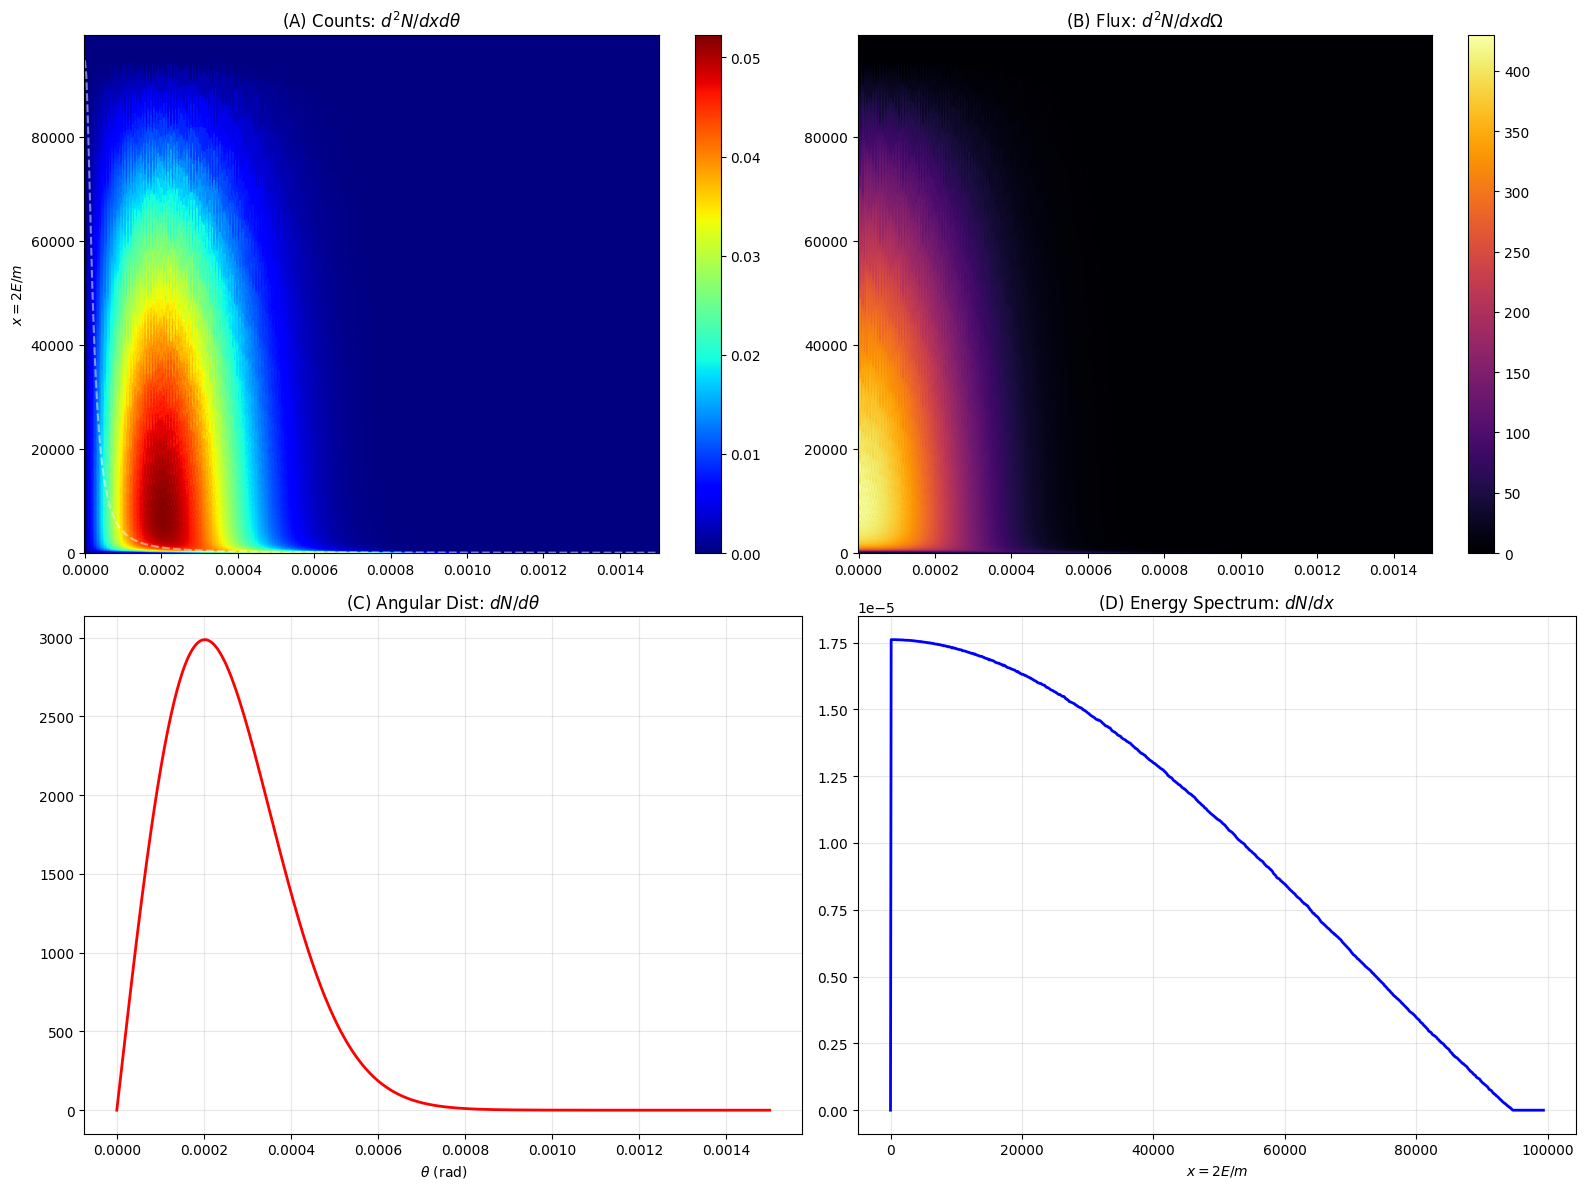

In [5]:
m_mu = 0.10566
E_mu_10TeVmuc = 5e3
E_mu_3TeVmuc = 1.5e3
betax = 0.0
betay = 0.0 
beta10TeV = (1-m_mu*m_mu/(E_mu_10TeVmuc)**2)**0.5
beta3TeV = (1-m_mu*m_mu/(E_mu_3TeVmuc)**2)**0.5
plot_muon_decay_comprehensive(beta=beta10TeV, sigma_betaT=2e-4, theta_max=1.5e-3, kind="nu_mu",
                average_betaT=True, n_theta=400, n_x=1000, n_phi=720, n_betaT=150)